# Phase 2 - Dataset EDA: Augmented Parking Dataset

This notebook explores the augmented parking dataset with JSON format annotations.

**Dataset Structure:**
- Images: JPG format, 640x640 pixels
- Annotations: JSON format with bounding boxes in pixel coordinates
- Classes: 2 classes (free/occupied parking spaces)
- Total images: ~36,426

**Key Differences from Phase 1:**
- JSON annotations instead of YOLO TXT format
- Only 2 classes (free vs occupied) vs 3 classes in Phase 1
- Much larger dataset (~36k images vs ~30 images)
- Augmented with rotations and other transformations

## 1. Imports & Path Setup


In [ ]:
import os
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
from collections import Counter
import sys

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == "Phase 2" else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Add report directory to path for utilities
sys.path.append(str(BASE_DIR / "report"))

# Import report utilities
try:
    from utils_report import save_plot, save_eda_plot, save_dataset_statistics, get_eda_dir
    REPORT_UTILS_AVAILABLE = True
except ImportError:
    print("Warning: Report utilities not available. Plots will not be saved.")
    REPORT_UTILS_AVAILABLE = False

# Augmented dataset paths
DATASET_ROOT = BASE_DIR / "data" / "processed" / "parking_dataset_augmented"
IMAGES_DIR = DATASET_ROOT / "images"
ANNOTATIONS_DIR = DATASET_ROOT / "annotations"
DATASET_INFO = DATASET_ROOT / "dataset_info.json"

print("BASE_DIR:", BASE_DIR)
print("Dataset root:", DATASET_ROOT)
print("Dataset root exists:", DATASET_ROOT.exists())
print("Images directory exists:", IMAGES_DIR.exists())
print("Annotations directory exists:", ANNOTATIONS_DIR.exists())
print("Dataset info exists:", DATASET_INFO.exists())

if REPORT_UTILS_AVAILABLE:
    REPORT_DIR = get_eda_dir()
    print(f"Report directory: {REPORT_DIR}")

# Class names (2 classes: free and occupied)
class_names = ["free_parking_space", "not_free_parking_space"]
class_to_id = {"free_parking_space": 0, "not_free_parking_space": 1}
id_to_class = {0: "free_parking_space", 1: "not_free_parking_space"}

print(f"\nClasses: {class_names}")


BASE_DIR: c:\Harosha\George Brown\DL2\parking-vision
Dataset root: c:\Harosha\George Brown\DL2\parking-vision\data\processed\parking_dataset_augmented
Dataset root exists: True
Images directory exists: True
Annotations directory exists: True
Dataset info exists: True
Report directory: c:\Harosha\George Brown\DL2\parking-vision\report\temp\phase1\eda

Classes: ['free_parking_space', 'not_free_parking_space']


## 2. Load Dataset Info & Basic Statistics


In [ ]:
# Load dataset info
if DATASET_INFO.exists():
    with open(DATASET_INFO, 'r') as f:
        dataset_info = json.load(f)
    
    print("Dataset Information:")
    print("=" * 60)
    print(f"Total images: {dataset_info['num_images']:,}")
    print(f"Target size: {dataset_info['target_size']}")
    print(f"Number of augmentations: {dataset_info.get('num_augmentations', 'N/A')}")
    print("=" * 60)
    
    # Get list of all images from dataset_info
    image_list = dataset_info.get('images', [])
    print(f"\nImage list length: {len(image_list):,}")
    
    # Sample first few entries
    print("\nSample image entries:")
    for i, img_info in enumerate(image_list[:5]):
        print(f"  {i+1}. {img_info['image']}: {img_info['num_spaces']} spaces, {img_info['num_occupied']} occupied")
else:
    print("Dataset info file not found!")
    dataset_info = None


Dataset Information:
Total images: 36,426
Target size: [640, 640]
Number of augmentations: 3

Image list length: 36,426

Sample image entries:
  1. img_000000.jpg: 90 spaces, 0 occupied
  2. img_000001.jpg: 90 spaces, 0 occupied
  3. img_000002.jpg: 90 spaces, 0 occupied
  4. img_000003.jpg: 90 spaces, 0 occupied
  5. img_000004.jpg: 86 spaces, 0 occupied


## 3. Inspect JSON Annotation Format


In [ ]:
# Get a sample annotation file
annotation_files = list(ANNOTATIONS_DIR.glob("*.json"))
print(f"Total annotation files: {len(annotation_files):,}")

if len(annotation_files) > 0:
    # Load a sample annotation
    sample_ann_path = annotation_files[0]
    print(f"\nSample annotation file: {sample_ann_path.name}")
    
    with open(sample_ann_path, 'r') as f:
        sample_ann = json.load(f)
    
    print("\nSample annotation structure:")
    print("=" * 60)
    print(f"Image name: {sample_ann.get('image_name', 'N/A')}")
    print(f"Image size: {sample_ann.get('image_size', 'N/A')}")
    print(f"Original image: {sample_ann.get('original_image', 'N/A')}")
    print(f"Parking lot: {sample_ann.get('parking_lot', 'N/A')}")
    print(f"Augmentation index: {sample_ann.get('augmentation_index', 'N/A')}")
    print(f"Number of spaces: {len(sample_ann.get('spaces', []))}")
    
    # Show sample space annotation
    if sample_ann.get('spaces'):
        print("\nSample space annotation:")
        sample_space = sample_ann['spaces'][0]
        print(f"  Bbox: {sample_space.get('bbox')} (format: [x_min, y_min, x_max, y_max])")
        print(f"  Occupied: {sample_space.get('occupied')}")
        print(f"  Class: {'not_free_parking_space' if sample_space.get('occupied') else 'free_parking_space'}")
    
    print("=" * 60)


Total annotation files: 36,426

Sample annotation file: img_000000.json

Sample annotation structure:
Image name: img_000000.jpg
Image size: [640, 640]
Original image: PUCPR/Cloudy/2012-09-12/2012-09-12_06_05_16.jpg
Parking lot: PUCPR
Augmentation index: 0
Number of spaces: 90

Sample space annotation:
  Bbox: [0, 7, 17, 76] (format: [x_min, y_min, x_max, y_max])
  Occupied: False
  Class: free_parking_space


## 4. Dataset Statistics Analysis


In [ ]:
# Analyze dataset statistics
print("Analyzing dataset statistics...")
print("=" * 60)

# Collect statistics
stats = {
    'num_spaces': [],
    'num_free': [],
    'num_occupied': [],
    'occupied_ratio': [],
    'augmentation_indices': [],
    'parking_lots': []
}

# Sample a subset for faster analysis (or analyze all)
SAMPLE_SIZE = 1000  # Analyze first 1000 for speed
annotation_files_sorted = sorted(annotation_files)[:SAMPLE_SIZE]

for ann_path in tqdm(annotation_files_sorted, desc="Processing annotations"):
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    
    spaces = ann.get('spaces', [])
    num_spaces = len(spaces)
    num_occupied = sum(1 for s in spaces if s.get('occupied', False))
    num_free = num_spaces - num_occupied
    
    stats['num_spaces'].append(num_spaces)
    stats['num_free'].append(num_free)
    stats['num_occupied'].append(num_occupied)
    stats['occupied_ratio'].append(num_occupied / num_spaces if num_spaces > 0 else 0.0)
    stats['augmentation_indices'].append(ann.get('augmentation_index', 0))
    
    parking_lot = ann.get('parking_lot', 'unknown')
    stats['parking_lots'].append(parking_lot)

# Convert to DataFrame for easy analysis
stats_df = pd.DataFrame(stats)

print(f"\nAnalyzed {len(stats_df):,} images")
print("\nBasic Statistics:")
print("=" * 60)
print(stats_df.describe())


Analyzing dataset statistics...


Processing annotations: 100%|██████████| 1000/1000 [00:01<00:00, 649.06it/s]



Analyzed 1,000 images

Basic Statistics:
        num_spaces     num_free  num_occupied  occupied_ratio  \
count  1000.000000  1000.000000   1000.000000     1000.000000   
mean     88.699000    30.172000     58.527000        0.660279   
std       2.724669    25.024521     24.941559        0.281047   
min      80.000000     2.000000      0.000000        0.000000   
25%      90.000000     7.000000     46.000000        0.511924   
50%      90.000000    24.500000     64.000000        0.722222   
75%      90.000000    42.000000     80.000000        0.922222   
max      90.000000    90.000000     87.000000        0.976190   

       augmentation_indices  
count           1000.000000  
mean               0.999000  
std                0.817109  
min                0.000000  
25%                0.000000  
50%                1.000000  
75%                2.000000  
max                2.000000  


### 4.1 Visualize Statistics


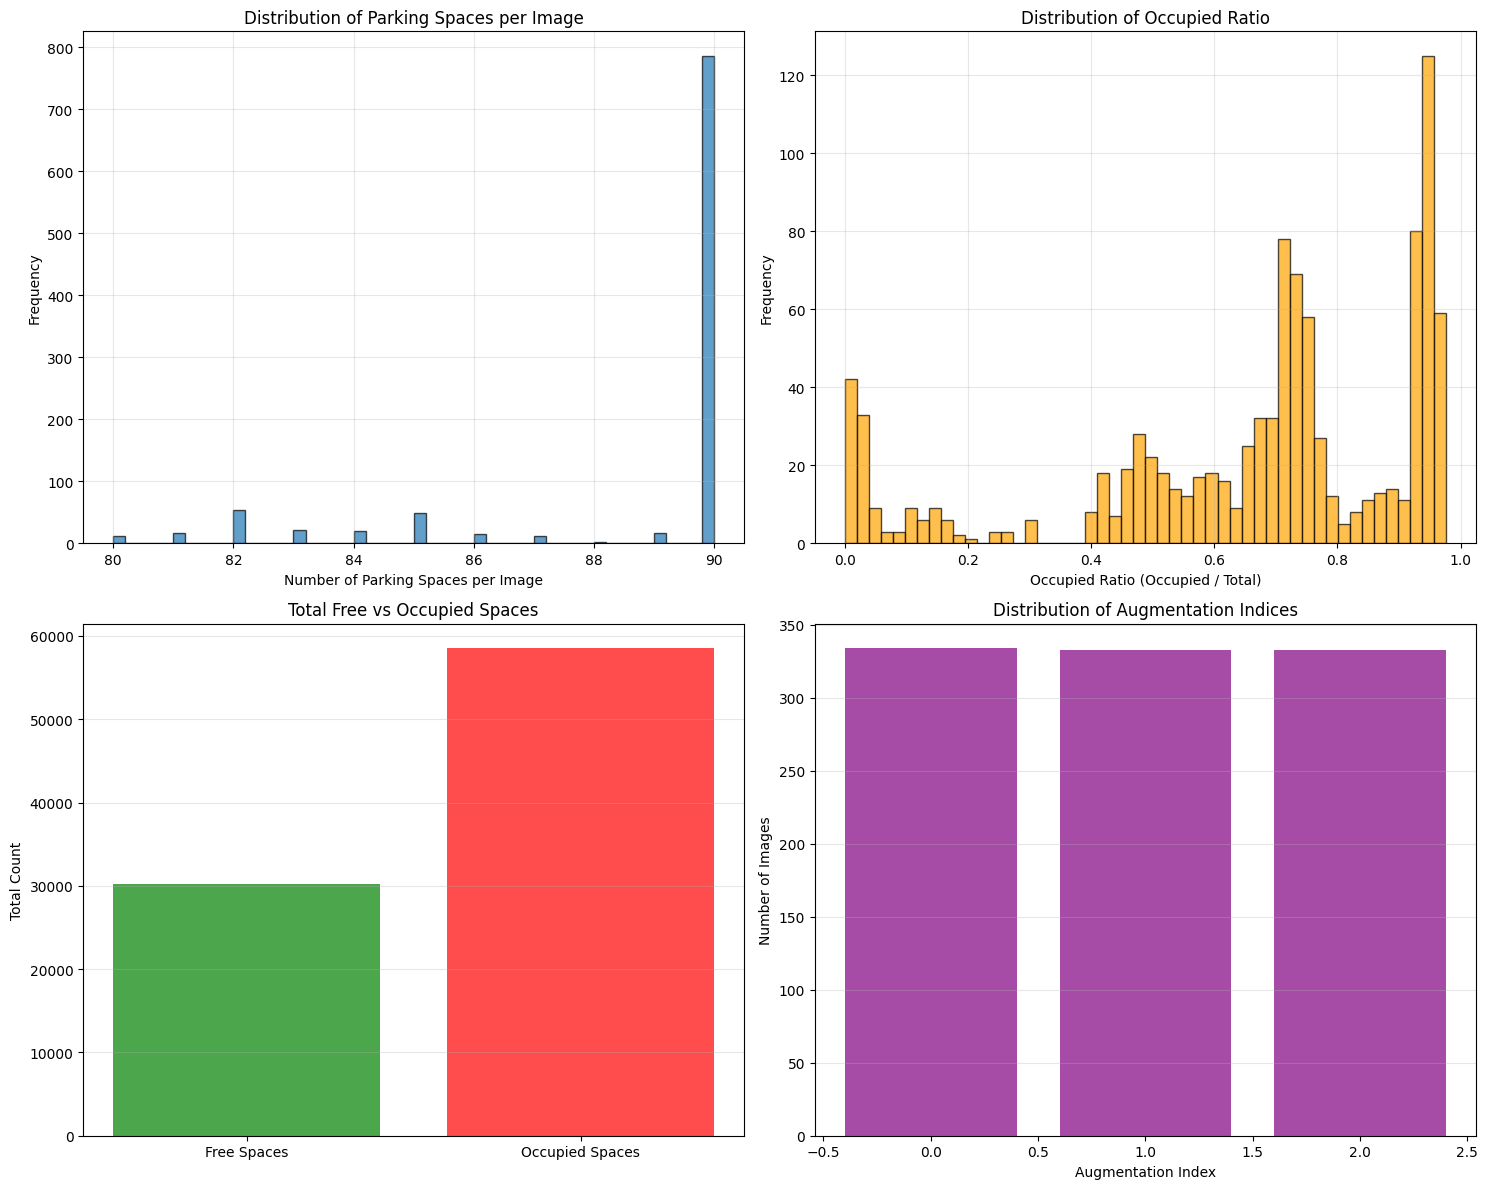

Saved EDA plot: c:\Harosha\George Brown\DL2\parking-vision\report\temp\phase1\eda\phase2_eda_statistics.png

Summary Statistics:
Total parking spaces analyzed: 88,699
Total free spaces: 30,172
Total occupied spaces: 58,527
Average spaces per image: 88.70
Average occupied ratio: 0.660
Parking lots in dataset: ['PUCPR']


In [ ]:
# Create visualization plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of number of spaces per image
axes[0, 0].hist(stats_df['num_spaces'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Parking Spaces per Image')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Parking Spaces per Image')
axes[0, 0].grid(True, alpha=0.3)

# 2. Occupied ratio distribution
axes[0, 1].hist(stats_df['occupied_ratio'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Occupied Ratio (Occupied / Total)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Occupied Ratio')
axes[0, 1].grid(True, alpha=0.3)

# 3. Free vs Occupied comparison
free_occupied_data = pd.DataFrame({
    'Class': ['Free Spaces', 'Occupied Spaces'],
    'Total': [stats_df['num_free'].sum(), stats_df['num_occupied'].sum()]
})
axes[1, 0].bar(free_occupied_data['Class'], free_occupied_data['Total'], color=['green', 'red'], alpha=0.7)
axes[1, 0].set_ylabel('Total Count')
axes[1, 0].set_title('Total Free vs Occupied Spaces')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Augmentation index distribution
aug_counts = stats_df['augmentation_indices'].value_counts().sort_index()
axes[1, 1].bar(aug_counts.index, aug_counts.values, alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Augmentation Index')
axes[1, 1].set_ylabel('Number of Images')
axes[1, 1].set_title('Distribution of Augmentation Indices')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Save the statistics visualization
if REPORT_UTILS_AVAILABLE:
    save_eda_plot(fig, "phase2_eda_statistics.png")

# Print summary statistics
print("\nSummary Statistics:")
print("=" * 60)
print(f"Total parking spaces analyzed: {stats_df['num_spaces'].sum():,}")
print(f"Total free spaces: {stats_df['num_free'].sum():,}")
print(f"Total occupied spaces: {stats_df['num_occupied'].sum():,}")
print(f"Average spaces per image: {stats_df['num_spaces'].mean():.2f}")
print(f"Average occupied ratio: {stats_df['occupied_ratio'].mean():.3f}")
print(f"Parking lots in dataset: {sorted(stats_df['parking_lots'].unique())}")


## 5. Visualize Sample Images with Bounding Boxes


In [ ]:
def visualize_image_with_boxes(image_path, annotation_path, max_boxes=100):
    """Visualize an image with bounding boxes drawn"""
    # Load image
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"Could not load image: {image_path}")
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Load annotation
    with open(annotation_path, 'r') as f:
        ann = json.load(f)
    
    # Draw bounding boxes
    spaces = ann.get('spaces', [])
    
    # Limit boxes for visualization
    spaces_to_show = spaces[:max_boxes]
    
    free_count = 0
    occupied_count = 0
    
    for space in spaces_to_show:
        bbox = space.get('bbox', [])
        occupied = space.get('occupied', False)
        
        if len(bbox) == 4:
            x_min, y_min, x_max, y_max = map(int, bbox)
            
            # Color: green for free, red for occupied
            color = (0, 255, 0) if not occupied else (255, 0, 0)
            thickness = 1
            
            cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), color, thickness)
            
            if occupied:
                occupied_count += 1
            else:
                free_count += 1
    
    return img_rgb, free_count, occupied_count, len(spaces)

print("Visualization function ready")


Visualization function ready


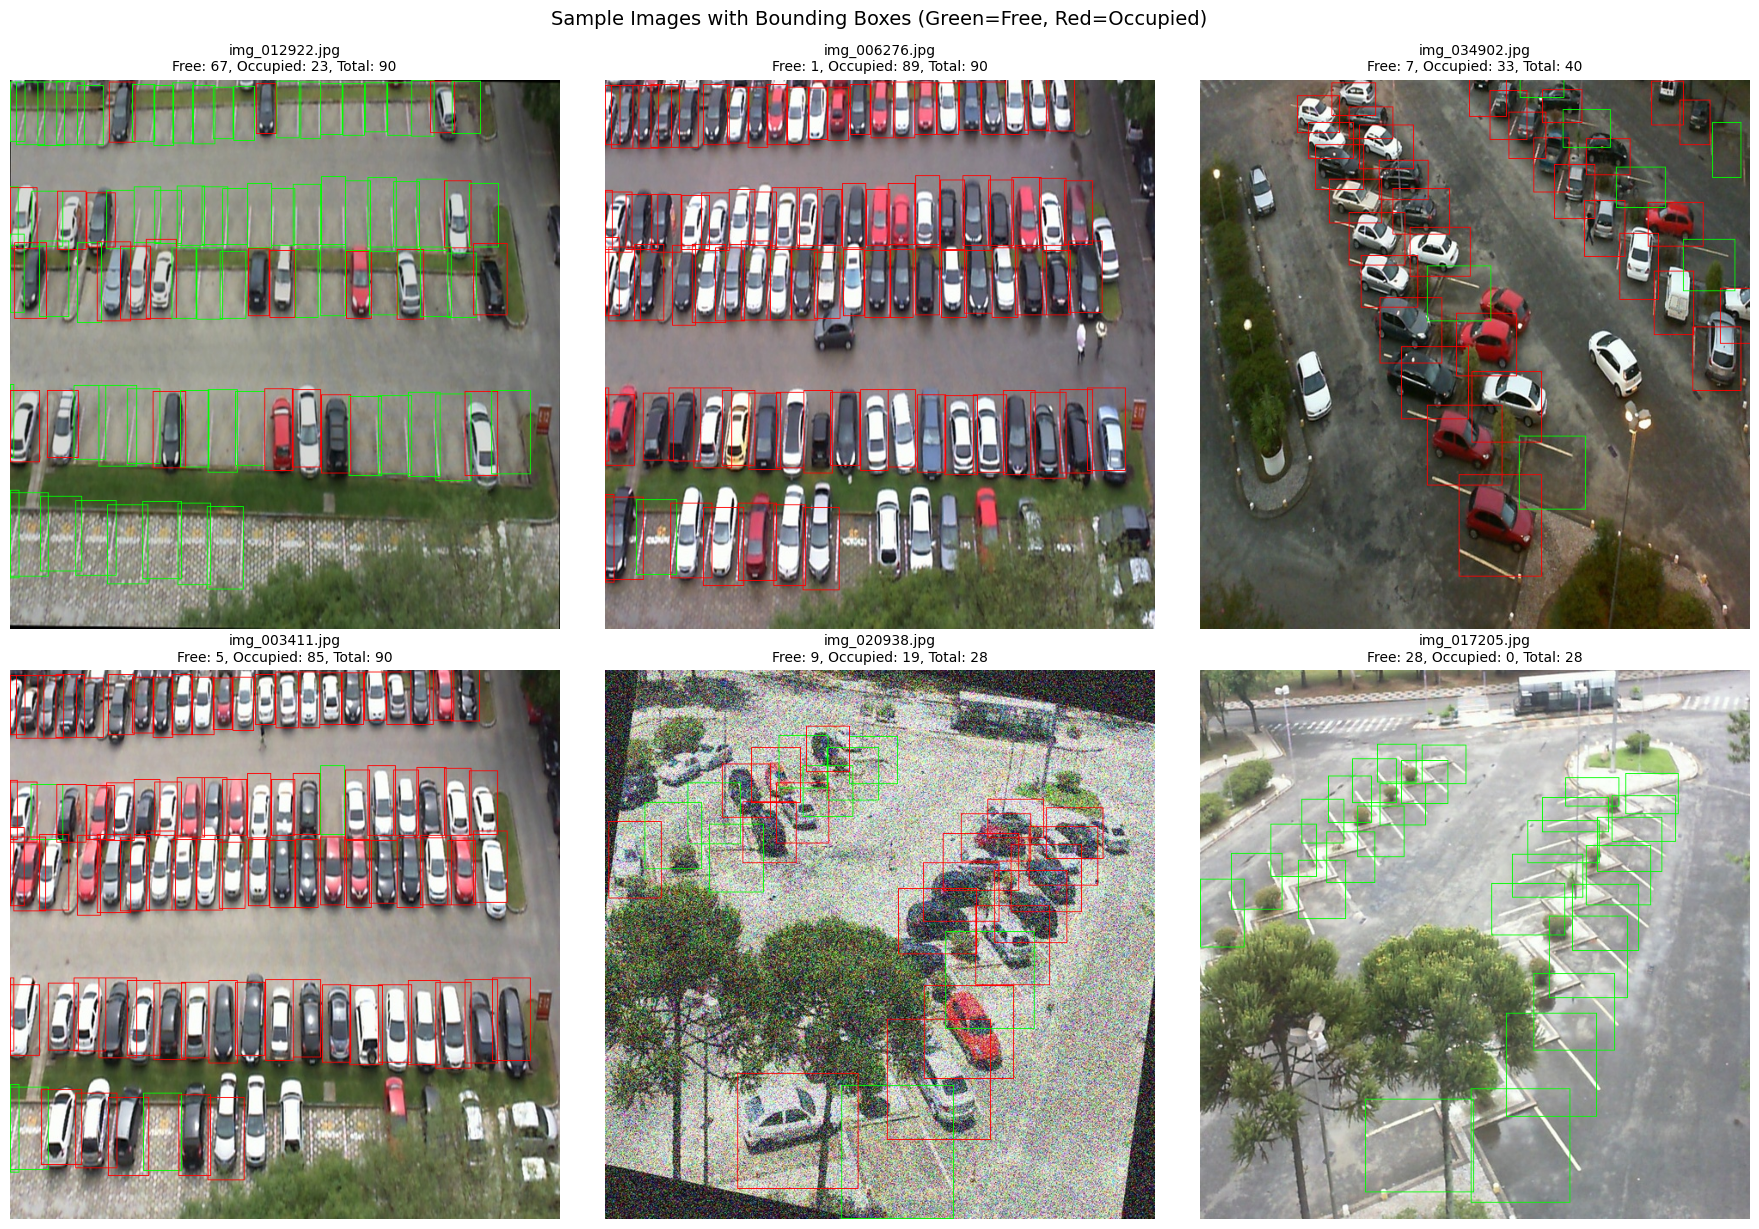

Saved EDA plot: c:\Harosha\George Brown\DL2\parking-vision\report\temp\phase1\eda\phase2_eda_sample_images.png


In [ ]:
# Visualize sample images
NUM_SAMPLES = 6
sample_indices = random.sample(range(len(annotation_files)), min(NUM_SAMPLES, len(annotation_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, ann_idx in enumerate(sample_indices):
    ann_path = annotation_files[ann_idx]
    img_name = ann_path.stem + ".jpg"
    img_path = IMAGES_DIR / img_name
    
    if img_path.exists():
        img_rgb, free_count, occupied_count, total_spaces = visualize_image_with_boxes(
            img_path, ann_path, max_boxes=100
        )
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(
            f"{img_name}\nFree: {free_count}, Occupied: {occupied_count}, Total: {total_spaces}",
            fontsize=10
        )
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f"Image not found:\n{img_name}", 
                      ha='center', va='center', fontsize=12)
        axes[idx].axis('off')

plt.tight_layout()
plt.suptitle("Sample Images with Bounding Boxes (Green=Free, Red=Occupied)", 
             fontsize=14, y=1.02)
plt.show()

# Save the sample images visualization
if REPORT_UTILS_AVAILABLE:
    save_eda_plot(fig, "phase2_eda_sample_images.png")


## 6. Bounding Box Analysis


In [ ]:
# Analyze bounding box sizes
print("Analyzing bounding box sizes...")
print("=" * 60)

box_widths = []
box_heights = []
box_areas = []
box_aspect_ratios = []

SAMPLE_SIZE_BBOX = 500  # Sample size for bbox analysis

for ann_path in tqdm(annotation_files_sorted[:SAMPLE_SIZE_BBOX], desc="Analyzing boxes"):
    with open(ann_path, 'r') as f:
        ann = json.load(f)
    
    for space in ann.get('spaces', []):
        bbox = space.get('bbox', [])
        if len(bbox) == 4:
            x_min, y_min, x_max, y_max = bbox
            width = x_max - x_min
            height = y_max - y_min
            area = width * height
            aspect_ratio = width / height if height > 0 else 0
            
            box_widths.append(width)
            box_heights.append(height)
            box_areas.append(area)
            box_aspect_ratios.append(aspect_ratio)

bbox_stats = pd.DataFrame({
    'width': box_widths,
    'height': box_heights,
    'area': box_areas,
    'aspect_ratio': box_aspect_ratios
})

print(f"\nAnalyzed {len(bbox_stats):,} bounding boxes")
print("\nBounding Box Statistics:")
print("=" * 60)
print(bbox_stats.describe())


Analyzing bounding box sizes...


Analyzing boxes: 100%|██████████| 500/500 [00:00<00:00, 1184.20it/s]



Analyzed 44,396 bounding boxes

Bounding Box Statistics:
              width        height          area  aspect_ratio
count  44396.000000  44396.000000  44396.000000  44396.000000
mean      32.389314     79.789193   2639.939927      0.411455
std        8.134965     13.777166    999.662427      0.103130
min        3.000000     20.000000    210.000000      0.038462
25%       28.000000     69.000000   1943.000000      0.371795
50%       32.000000     81.000000   2430.000000      0.414634
75%       37.000000     90.000000   3256.000000      0.448718
max       57.000000    120.000000   6328.000000      1.714286


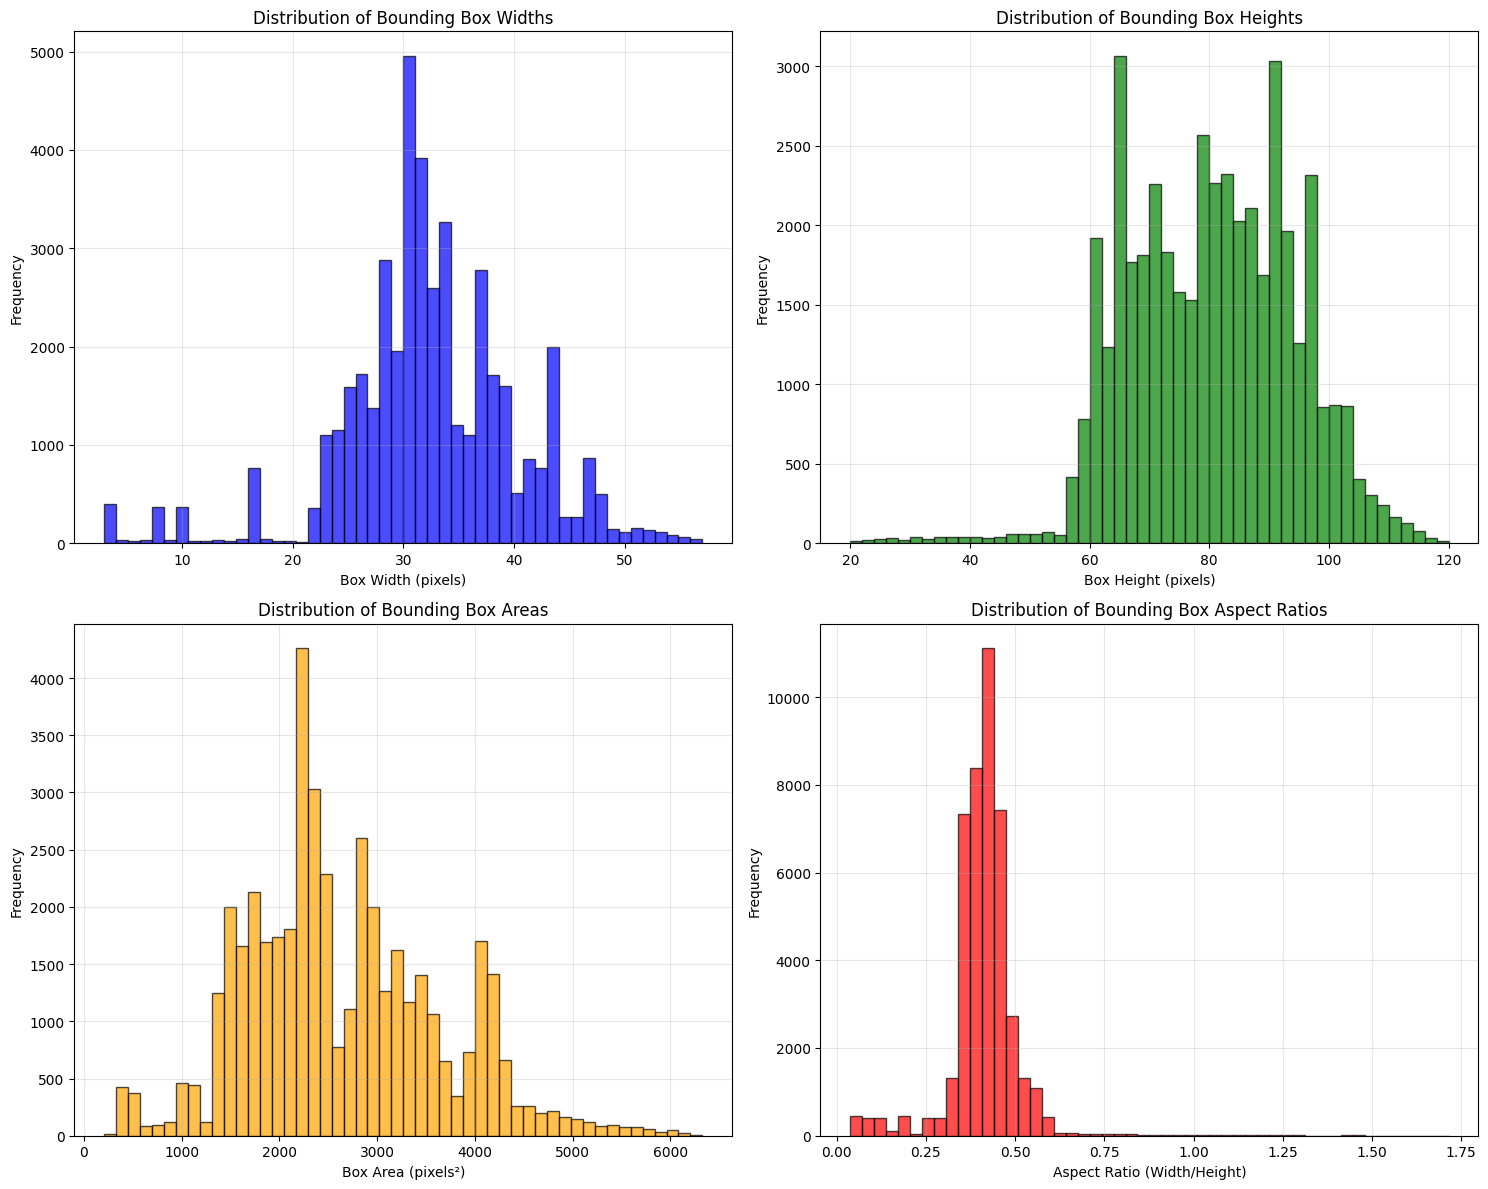

Saved EDA plot: c:\Harosha\George Brown\DL2\parking-vision\report\temp\phase1\eda\phase2_eda_bbox_statistics.png


In [ ]:
# Visualize bounding box statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Width distribution
axes[0, 0].hist(bbox_stats['width'], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].set_xlabel('Box Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Bounding Box Widths')
axes[0, 0].grid(True, alpha=0.3)

# 2. Height distribution
axes[0, 1].hist(bbox_stats['height'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Box Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Bounding Box Heights')
axes[0, 1].grid(True, alpha=0.3)

# 3. Area distribution
axes[1, 0].hist(bbox_stats['area'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Box Area (pixels²)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Bounding Box Areas')
axes[1, 0].grid(True, alpha=0.3)

# 4. Aspect ratio distribution
axes[1, 1].hist(bbox_stats['aspect_ratio'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Aspect Ratio (Width/Height)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Bounding Box Aspect Ratios')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the bounding box statistics visualization
if REPORT_UTILS_AVAILABLE:
    save_eda_plot(fig, "phase2_eda_bbox_statistics.png")


## 7. Dataset Summary & Notes for Training


In [ ]:
print("Dataset Summary for Training")
print("=" * 60)
print(f"Total images: {len(annotation_files):,}")
print(f"Image size: 640x640 pixels")
print(f"Classes: {len(class_names)} ({', '.join(class_names)})")
print(f"\nClass mapping:")
for class_name, class_id in class_to_id.items():
    print(f"  {class_id}: {class_name}")

print(f"\nAnnotation format:")
print(f"  - Format: JSON")
print(f"  - Bbox format: [x_min, y_min, x_max, y_max] (pixel coordinates)")
print(f"  - Occupied flag: boolean (False=free, True=occupied)")

print(f"\nDataset location:")
print(f"  Images: {IMAGES_DIR}")
print(f"  Annotations: {ANNOTATIONS_DIR}")

print(f"\nKey insights:")
print(f"  - Average spaces per image: {stats_df['num_spaces'].mean():.2f}")
print(f"  - Average occupied ratio: {stats_df['occupied_ratio'].mean():.3f}")
print(f"  - Average box width: {bbox_stats['width'].mean():.2f} pixels")
print(f"  - Average box height: {bbox_stats['height'].mean():.2f} pixels")
print("=" * 60)

# Save dataset summary statistics
if REPORT_UTILS_AVAILABLE:
    summary_stats = {
        "Total images": f"{len(annotation_files):,}",
        "Image size": "640x640 pixels",
        "Classes": f"{len(class_names)} ({', '.join(class_names)})",
        "Average spaces per image": f"{stats_df['num_spaces'].mean():.2f}",
        "Average occupied ratio": f"{stats_df['occupied_ratio'].mean():.3f}",
        "Average box width": f"{bbox_stats['width'].mean():.2f} pixels",
        "Average box height": f"{bbox_stats['height'].mean():.2f} pixels",
        "Total parking spaces analyzed": f"{stats_df['num_spaces'].sum():,}",
        "Total free spaces": f"{stats_df['num_free'].sum():,}",
        "Total occupied spaces": f"{stats_df['num_occupied'].sum():,}"
    }
    save_dataset_statistics(summary_stats, "phase2_eda_summary.txt")


Dataset Summary for Training
Total images: 36,426
Image size: 640x640 pixels
Classes: 2 (free_parking_space, not_free_parking_space)

Class mapping:
  0: free_parking_space
  1: not_free_parking_space

Annotation format:
  - Format: JSON
  - Bbox format: [x_min, y_min, x_max, y_max] (pixel coordinates)
  - Occupied flag: boolean (False=free, True=occupied)

Dataset location:
  Images: c:\Harosha\George Brown\DL2\parking-vision\data\processed\parking_dataset_augmented\images
  Annotations: c:\Harosha\George Brown\DL2\parking-vision\data\processed\parking_dataset_augmented\annotations

Key insights:
  - Average spaces per image: 88.70
  - Average occupied ratio: 0.660
  - Average box width: 32.39 pixels
  - Average box height: 79.79 pixels
Saved dataset statistics: c:\Harosha\George Brown\DL2\parking-vision\report\temp\phase1\eda\phase2_eda_summary.txt
